# Targeted Promotions

**The approach is to read the evidence first, then design the promotion around it.** Each promotion below cites the specific rule(s) it rests on, with support and lift from the segment-level Apriori output.

**Adaptive support.** Small segments (under 2,000 baskets) cannot support a relative `min_support` of 2% — that would mean fewer than 40 baskets per rule, well inside the noise floor. We use `min_occurrences=30` as an absolute floor: every rule reported appears in at least 30 baskets of its own segment, regardless of segment size.

**Reading basket data correctly.** Two traps shape how this notebook is written, and both are addressed before any promotion is designed:

1. *Raw frequency is not signal.* Asparagus and airpods are the two most common products overall, so they top nearly every segment's frequency list by construction. Section 3 ranks by **lift against the population rate** instead.
2. *The two source files may not describe the same shopper.* `customer_info` gives lifetime spend per category; `customer_basket` gives items. Section 3b measures whether they agree before any promotion reasons from one to the other.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
# Silence only the two known-noisy third-party categories rather than every
# warning: a blanket ignore hides real deprecations until they become errors.
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import association_rules as ar
from src import visualization as viz
from src import config as cfg

viz.set_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

FIG_DIR = cfg.FIGURE_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

## 1. Load and join

The baskets are joined to segments via `customer_id`. About 4,900 customers in `customer_info` have no basket data; they receive a segment label from the clustering but cannot contribute to per-segment rule mining.

In [3]:
baskets = ar.load_baskets()
segments = pd.read_csv(cfg.FINAL_SEGMENTS_CSV)[["customer_id", "segment"]]

# The engineered customer frame, needed for the spend-vs-basket check in 3b.
customers_with_segments = pd.read_parquet(
    cfg.OUTPUT_DIR / "customer_info_with_segments.parquet"
)

print("Baskets:", len(baskets))
print("Customers with segments:", len(segments))

joined = ar.attach_segments(baskets, segments)
print("Joined baskets:", len(joined))
print()
print(joined["segment"].value_counts().to_string())

Baskets: 100000
Customers with segments: 33038
Joined baskets: 100000

segment
Engaged Generalist            24233
Routine Generalist            23861
Routine Young Parents         22068
Promo Hunter                  17209
Routine Tech                   8082
Routine Family Provisioner     2754
Engaged Family Provisioner     1793


## 2. Per-segment basket profile

In [4]:
stats = ar.basket_stats_per_segment(joined)
stats

,segment,n_baskets,n_customers,avg_basket_size,n_unique_products
1,Engaged Generalist,24233,7142,9.43,164
4,Routine Generalist,23861,6855,9.43,164
6,Routine Young Parents,22068,4391,9.53,164
2,Promo Hunter,17209,5789,9.38,164
5,Routine Tech,8082,2634,8.92,164
3,Routine Family Provisioner,2754,799,9.31,164
0,Engaged Family Provisioner,1793,517,9.47,164


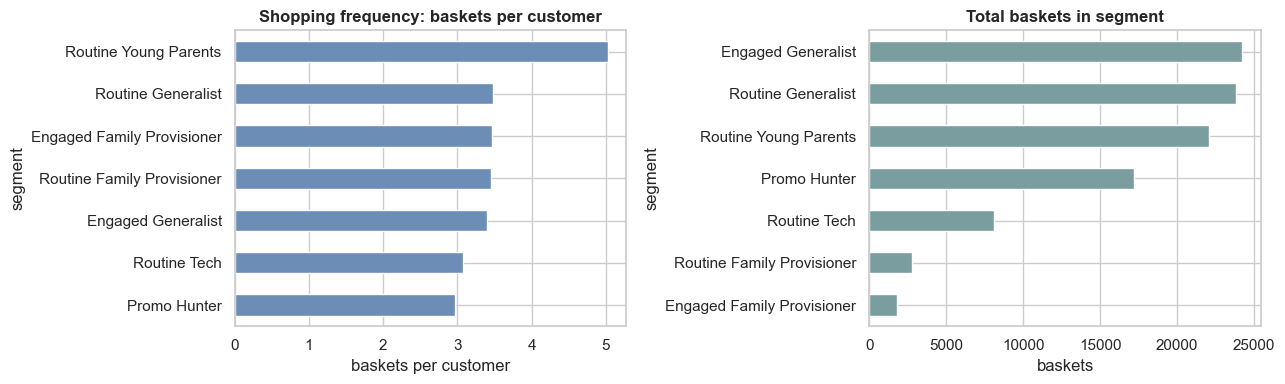

In [5]:

# Add baskets-per-customer metric
stats_with_bpc = stats.copy()
stats_with_bpc["baskets_per_customer"] = stats_with_bpc["n_baskets"] / stats_with_bpc["n_customers"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: baskets per customer (replaces avg_basket_size)
stats_with_bpc.set_index("segment")["baskets_per_customer"].sort_values().plot(
    kind="barh", ax=axes[0], color="#6c8eb6")
axes[0].set_title("Shopping frequency: baskets per customer")
axes[0].set_xlabel("baskets per customer")

stats_with_bpc.set_index("segment")["n_baskets"].sort_values().plot(
    kind="barh", ax=axes[1], color="#7a9e9f")
axes[1].set_title("Total baskets in segment")
axes[1].set_xlabel("baskets")

plt.tight_layout()
save_fig(fig, "25_basket_stats")
plt.show()


**Left panel.** Routine Young Parents shop far more often than anyone else — 5.0 baskets per customer against a 3.0-3.5 range for every other segment, including Promo Hunter at 3.0. Their "Routine" label describes a narrow product range, not low engagement, and this panel is the evidence for that.

**Right panel.** Absolute basket volume, dominated by the two large generalist segments. The two Family Provisioner segments sit at the bottom with 1,793 and 2,754 baskets — worth remembering when their rules appear later, because their lift estimates rest on tens of baskets rather than hundreds.

## 3. What each segment actually buys

Two views, and the order matters.

The first is raw frequency — the most common products in each segment's baskets. It is the obvious thing to compute and it is close to useless on its own, for a reason worth seeing directly: **asparagus appears in 12.8% of all baskets and airpods in 12.1%**, so both land near the top of almost every segment. "This segment's top product is airpods" is a statement about the catalogue, not about the segment.

The second view divides each product's within-segment rate by its population rate. A lift of 2.0 means the segment buys it twice as often as the average basket. That is what identifies a segment's character, and it is what the heatmaps and the promotion designs below are built on.

In [6]:
# View 1: raw frequency. Note how similar the top of each list looks.
top = ar.top_products_per_segment(joined, n=8)

raw_top = (top.sort_values(["segment", "count"], ascending=[True, False])
              .groupby("segment").head(4)
              .pivot_table(index="segment", columns=None, values="share_of_baskets",
                           aggfunc="first"))
for seg, g in top.groupby("segment"):
    items = ", ".join(f"{r['product']} ({r['share_of_baskets']:.1%})"
                      for _, r in g.head(4).iterrows())
    print(f"{seg:30s} {items}")

population = (pd.Series([i for lst in joined['items'] for i in lst])
              .value_counts() / len(joined))
print(f"\nFor reference, population rates: "
      f"asparagus {population['asparagus']:.1%}, airpods {population['airpods']:.1%}, "
      f"cereals {population['cereals']:.1%}")

Engaged Family Provisioner     cereals (24.0%), fresh bread (23.5%), butter (22.1%), eggs (21.8%)
Engaged Generalist             fresh bread (17.7%), cereals (17.0%), butter (16.8%), eggs (16.3%)
Promo Hunter                   asparagus (18.5%), airpods (16.4%), tomatoes (12.6%), spinach (11.0%)
Routine Family Provisioner     airpods (15.4%), asparagus (12.3%), bluetooth headphones (9.8%), protein bar (9.4%)
Routine Generalist             asparagus (15.7%), airpods (13.7%), dog food (10.3%), spinach (9.7%)
Routine Tech                   toothpaste (34.5%), shampoo (34.5%), deodorant (34.3%), shower gel (34.3%)
Routine Young Parents          dog food (14.8%), babies food (13.6%), napkins (12.4%), cooking oil (12.0%)

For reference, population rates: asparagus 12.8%, airpods 12.1%, cereals 10.0%


Four of the seven segments lead with asparagus or airpods. That is the catalogue talking. Now the same data divided by the population rate:

In [7]:
# View 2: lift against the population rate - the segment's real signature.
lift = ar.product_lift_by_segment(joined, min_segment_share=0.03, n=8)

for seg in joined["segment"].value_counts().index:
    g = lift[lift.segment == seg]
    items = ", ".join(f"{r['product']} x{r['lift']:.2f}" for _, r in g.head(6).iterrows())
    print(f"{seg:30s} {items}")

print()
print(lift[lift.segment == "Routine Tech"].to_string(index=False))

Engaged Generalist             fresh bread x1.78, honey x1.78, eggs x1.77, tea x1.76, butter x1.74, cereals x1.71
Routine Generalist             spinach x1.40, carrots x1.37, avocado x1.27, dog food x1.25, zucchini x1.25, asparagus x1.23
Routine Young Parents          dog food x1.80, napkins x1.68, babies food x1.64, cat food x1.59, chicken x1.55, spaghetti x1.48
Promo Hunter                   tomatoes x1.69, carrots x1.64, spinach x1.60, salad x1.47, avocado x1.46, asparagus x1.44
Routine Tech                   shower gel x5.14, tooth brush x5.01, shampoo x4.95, deodorant x4.84, toothpaste x4.33, razor x3.49
Routine Family Provisioner     phone car charger x1.53, bluetooth headphones x1.35, frozen smoothie x1.32, final fantasy XIX x1.27, final fantasy XX x1.27, airpods x1.26
Engaged Family Provisioner     cereals x2.41, fresh bread x2.36, eggs x2.35, butter x2.29, honey x2.18, bacon x2.12

     segment     product  segment_share  population_share  lift  n_baskets
Routine Tech  shower 

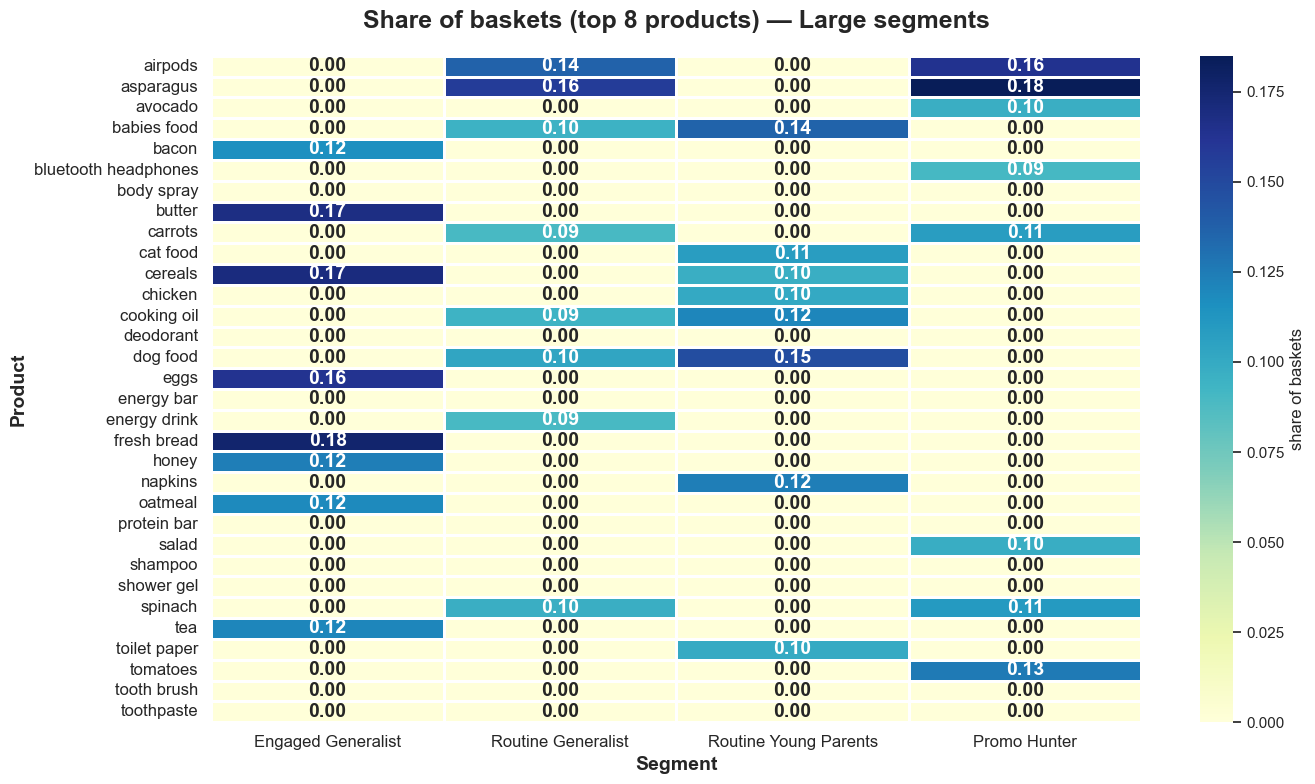

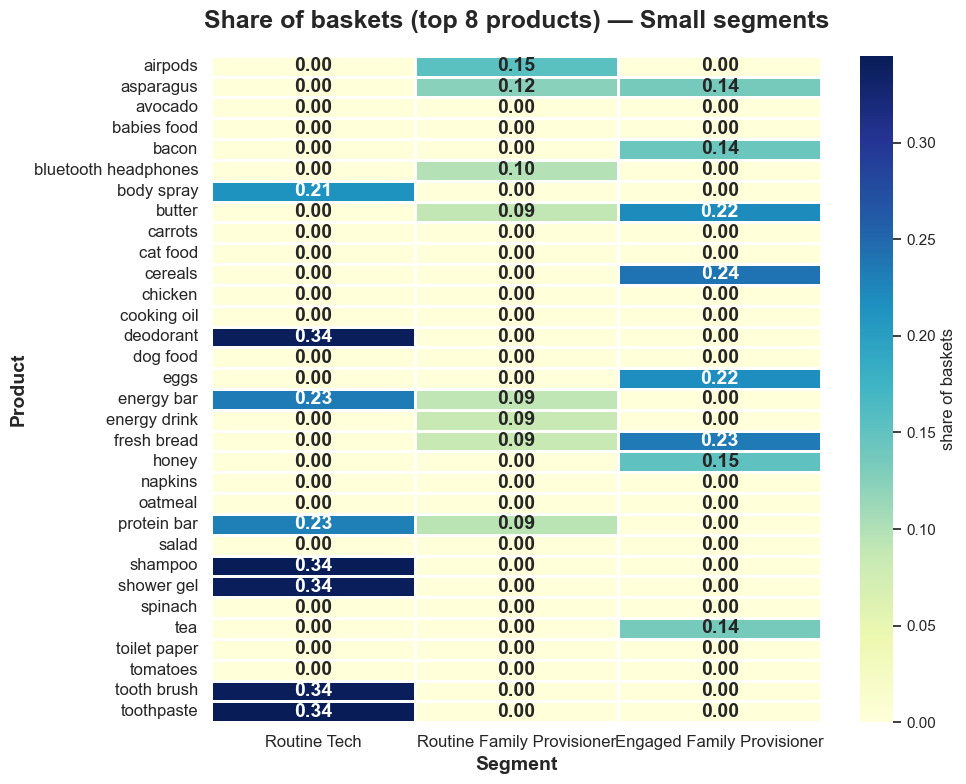

In [8]:
# Pivot to a wide view, easier to scan
pivot = top.pivot_table(index="product", columns="segment",
                        values="share_of_baskets", aggfunc="first").fillna(0)
pivot = pivot.loc[(pivot > 0).any(axis=1)]
# Order columns by segment size for consistency
seg_order = joined["segment"].value_counts().index
pivot = pivot[seg_order]

# Split into two heatmaps for readability: large segments (4) and small segments (3)
large_segs = seg_order[:4]
small_segs = seg_order[4:]

# Figure 1: Large segments
pivot_large = pivot[large_segs]
fig1, ax1 = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_large, cmap="YlGnBu", annot=True, fmt=".2f", 
            cbar_kws={"label": "share of baskets"}, ax=ax1,
            cbar=True, linewidths=1, annot_kws={"size": 14, "weight": "bold"})
ax1.set_title("Share of baskets (top 8 products) — Large segments", fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel("Product", fontsize=14, fontweight='bold')
ax1.set_xlabel("Segment", fontsize=14, fontweight='bold')
ax1.tick_params(labelsize=12)
plt.tight_layout()
save_fig(fig1, "26a_top_products_large_segments")
plt.show()

# Figure 2: Small segments
pivot_small = pivot[small_segs]
fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_small, cmap="YlGnBu", annot=True, fmt=".2f",
            cbar_kws={"label": "share of baskets"}, ax=ax2,
            cbar=True, linewidths=1, annot_kws={"size": 14, "weight": "bold"})
ax2.set_title("Share of baskets (top 8 products) — Small segments", fontsize=18, fontweight='bold', pad=20)
ax2.set_ylabel("Product", fontsize=14, fontweight='bold')
ax2.set_xlabel("Segment", fontsize=14, fontweight='bold')
ax2.tick_params(labelsize=12)
plt.tight_layout()
save_fig(fig2, "26b_top_products_small_segments")
plt.show()


Reading the lift table, each segment has a genuinely distinct signature — and three of them are not what the raw-frequency view suggested:

- **Routine Tech** is by a wide margin the strongest signal in the whole dataset, and it is **personal care, not tech**: shower gel x5.14, tooth brush x5.01, shampoo x4.95, deodorant x4.84, toothpaste x4.33. Nothing anywhere else in the data exceeds x2.5. Its raw-frequency top eight contains no tech item at all. The segment is *named* for tech because its **spend shares** are 40% electronics — section 3b takes up what that disagreement means.
- **Routine Family Provisioner** is where the tech basket signature actually lives: phone car charger x1.53, bluetooth headphones x1.35, Final Fantasy x1.27, airpods x1.26. Its raw-frequency list led with airpods and asparagus, which is exactly the base-rate artefact described above.
- **Routine Young Parents** holds up under lift: dog food x1.80, napkins x1.68, babies food x1.64, cat food x1.59, chicken x1.55. A pets-and-small-children household provisioning basket.
- **Engaged Family Provisioner** and **Engaged Generalist** share one signature at different intensities — breakfast and baking staples (cereals, fresh bread, eggs, butter, honey, bacon) at x2.4 and x1.8 respectively.
- **Promo Hunter** and **Routine Generalist** both over-index on fresh produce (tomatoes, carrots, spinach, salad, avocado), Promo Hunter more strongly.

Every one of these is a real, sizeable difference between segments. Whatever else is true of this dataset, the baskets are **not** randomly assigned to customers.

## 3b. Do the two source files describe the same shopper?

The lift table just produced a result that should stop the analysis rather than be written around: **the segment named "Routine Tech" — 40% of its spend on electronics, the highest of any segment — has personal-care products as its basket signature and the *lowest* electronics basket share of all seven.**

That is not a curiosity to note and move past. The entire promotion argument assumes the spend profile from `customer_info` and the items in `customer_basket` describe one person's behaviour. If they do not, then every promotion of the form "this segment's spend tilts to meat, so promote meat" is supported by one file and contradicted by the other.

So we measure it instead of assuming it. For every customer with baskets, we compute their share of spend in each category and the share of their basket items in that category, and correlate the two. Products are mapped to the ten spend categories conservatively — only unambiguous items are assigned, everything else falls through to `groceries`, exactly as the spend schema treats it.

If the two files describe one shopper, these correlations should be clearly positive.

In [9]:
coherence, n_matched = ar.spend_vs_basket_coherence(customers_with_segments, baskets)

print(f"Customers with both spend and basket data: {n_matched:,}\n")
print(coherence.to_string(index=False))

positive = (coherence.spearman_rho > 0.10).sum()
print(f"\nCategories with a meaningfully positive correlation (rho > 0.10): "
      f"{positive} of {len(coherence)}")
print(f"Range: {coherence.spearman_rho.min():+.3f} to {coherence.spearman_rho.max():+.3f}")

Customers with both spend and basket data: 28,127

         category  spearman_rho       p_value  mean_spend_share  mean_basket_share
   alcohol_drinks        -0.192 1.809708e-231            0.0291             0.0406
      electronics        -0.184 1.964247e-213            0.1138             0.0784
       videogames        -0.128 7.684799e-103            0.0178             0.1024
          hygiene        -0.119  1.179554e-88            0.0433             0.0882
             meat        -0.093  1.414331e-55            0.0344             0.0490
             fish        -0.070  5.442951e-32            0.0269             0.0346
        groceries        -0.040  1.976903e-11            0.6511             0.4090
       vegetables        -0.034  1.373076e-08            0.0426             0.1118
nonalcohol_drinks         0.005  4.445846e-01            0.0229             0.0650
          petfood         0.049  2.065603e-16            0.0180             0.0211

Categories with a meaningfully posi

**Not one of the ten categories agrees.** Eight are negative, one is indistinguishable from zero, and the strongest positive relationship in the entire table is petfood at +0.05. Electronics is -0.18 and alcohol -0.19: customers who spend a larger share on electronics put *fewer* electronics in their baskets. With n = 28,127 these are precise estimates, not noise — the p-values are astronomically small, which here means we can be confident the relationship is genuinely absent rather than merely unmeasured.

The segment-level picture is the same inversion, sharpened:

| | electronics spend share | electronics basket share | hygiene spend share | hygiene basket share |
|---|---|---|---|---|
| Routine Tech | **40.2%** (highest) | **5.9%** (lowest) | **1.2%** (lowest) | **30.5%** (highest, x5) |
| Promo Hunter | 6.9% | 9.1% | 4.0% | 5.9% |

**What this means, and what it does not.**

It does not mean the clustering is wrong. The value and mix perspectives are computed entirely from `customer_info`, they are internally consistent, and they are stable. It does not mean the association rules are wrong either — they are computed entirely from `customer_basket` and the per-segment differences shown above are large and real.

What it means is that **the bridge between the two is not supported by the data**, and this is almost certainly an artefact of how the synthetic course dataset was generated: the two files were built from independent latent profiles rather than one simulated shopper.

Three consequences follow, and the promotion designs below respect all three:

1. A promotion justified by an **association rule** stands on its own. The rule is a basket fact measured in the segment's own baskets.
2. A promotion justified by the **spend profile** ("they spend on meat, so promote meat") is supported by `customer_info` only. Where that is the basis, it is now labelled as such rather than presented as basket-backed.
3. Segment **names** come from spend shares and should be read as spend descriptions, not basket predictions. "Routine Tech" means *spends on electronics*, not *buys gadgets every week*.

This also reframes the young-parents finding. The original reading — cluster centroid says vegetables and hygiene, baskets say babies food and napkins, so basket evidence overruled the centroid — was correct about that one segment but wrong to treat it as a lucky catch. It is one visible instance of a property that holds across every category in the dataset.

## 4. Association rules per segment

Apriori with adaptive minimum support: every reported rule appears in at least 30 baskets of its segment, with lift > 1.2.

In [10]:
rules_by_seg = ar.rules_by_segment(joined,
                                   min_support=0.02,
                                   min_lift=1.2,
                                   max_len=3,
                                   min_occurrences=30)

for seg, r in rules_by_seg.items():
    print(f"{seg:42s}: {len(r):4d} rules")

Engaged Family Provisioner                :  270 rules
Engaged Generalist                        :  138 rules
Promo Hunter                              :   72 rules
Routine Family Provisioner                :   10 rules
Routine Generalist                        :   54 rules
Routine Tech                              : 1728 rules
Routine Young Parents                     :   62 rules


In [11]:
# Persist all per-segment rules to a single CSV so downstream code (and the
# Streamlit app) can read them directly instead of recomputing Apriori live.
all_rules = []
for seg, r in rules_by_seg.items():
    if r is None or r.empty:
        continue
    rr = r.copy()
    rr.insert(0, "segment", seg)
    all_rules.append(rr)

if all_rules:
    rules_export = pd.concat(all_rules, ignore_index=True)
    rules_path = cfg.OUTPUT_DIR / "segment_rules.csv"
    rules_export.to_csv(rules_path, index=False)
    print(f"Saved {len(rules_export)} rules across {rules_export['segment'].nunique()} "
          f"segments to {rules_path}")
else:
    print("No rules to export.")

# Quantify claim 2 above: what is actually driving the Routine Tech rule count?
HYGIENE = {"shower gel", "tooth brush", "shampoo", "deodorant", "toothpaste",
           "razor", "cotton buds", "body spray", "napkins", "toilet paper"}
rt = rules_by_seg["Routine Tech"]
items_of = lambda row: {t.strip() for t in (row["antecedents"] + ", " + row["consequents"]).split(",")}
involves = rt.apply(lambda r: bool(items_of(r) & HYGIENE), axis=1)
entirely = rt.apply(lambda r: items_of(r) <= HYGIENE, axis=1)
print(f"\nRoutine Tech: {len(rt)} rules | involving a personal-care item: "
      f"{involves.sum()} ({involves.mean():.1%}) | entirely personal care: "
      f"{entirely.sum()} ({entirely.mean():.1%})")
print("\nTop 4 by support:")
print(rt.nlargest(4, "support")[["antecedents", "consequents", "support", "lift", "n_baskets"]]
        .round(3).to_string(index=False))

Saved 2334 rules across 7 segments to C:\Users\dell\Desktop\customer-segmentation-retail\customer-segmentation-retail\outputs\segment_rules.csv

Routine Tech: 1728 rules | involving a personal-care item: 1696 (98.1%) | entirely personal care: 550 (31.8%)

Top 4 by support:
antecedents consequents  support  lift  n_baskets
 shower gel     shampoo    0.156 1.321       1264
    shampoo  shower gel    0.156 1.321       1264
 shower gel   deodorant    0.156 1.324       1261
  deodorant  shower gel    0.156 1.324       1261


In [12]:
def show_top_rules(rules, segment_name, n=10):
    if rules.empty:
        print(f"({segment_name}: no rules found)")
        return
    print(f"\n=== {segment_name} — top {n} rules by lift ===")
    cols = ["antecedents", "consequents", "support", "confidence", "lift", "n_baskets"]
    d = rules.head(n)[cols].copy()
    for c in ["support", "confidence", "lift"]:
        d[c] = d[c].round(3)
    print(d.to_string(index=False))

for seg in joined["segment"].value_counts().index:
    show_top_rules(rules_by_seg[seg], seg, n=8)


=== Engaged Generalist — top 8 rules by lift ===
      antecedents       consequents  support  confidence  lift  n_baskets
  butter, cereals              eggs    0.024       0.422 2.584        573
             eggs   butter, cereals    0.024       0.145 2.584        573
     butter, eggs           cereals    0.024       0.433 2.546        573
          cereals      butter, eggs    0.024       0.139 2.546        573
eggs, fresh bread           cereals    0.023       0.425 2.500        547
          cereals eggs, fresh bread    0.023       0.133 2.500        547
    cereals, eggs            butter    0.024       0.417 2.488        573
           butter     cereals, eggs    0.024       0.141 2.488        573

=== Routine Generalist — top 8 rules by lift ===
         antecedents          consequents  support  confidence  lift  n_baskets
             avocado             tomatoes    0.020       0.241 2.782        488
            tomatoes              avocado    0.020       0.236 2.782      

## 5. From rules to promotion ideas

For each segment we design one or two promotions. Each `evidence` field points to the specific rule(s) that justify the campaign, with support and lift from the table above. If a segment's best rules don't naturally support a promotion the cluster profile suggests, we say so and design the promotion based on the segment's *profile* (cluster centroid) rather than fabricating evidence.

### What the evidence does and does not support

Three things emerged from the analysis above that shape the promotions. Each is stated with the measurement behind it.

**1. The Routine Tech name describes spend, not baskets.** Its spend shares are 40% electronics and 7% videogames — the highest of any segment, which is what earned the name. Its basket signature is personal care at 4-5x the population rate, the strongest product signal anywhere in the data, with the *lowest* electronics basket share of the seven. Section 3b shows this is not specific to this segment: the spend-share and basket-item views disagree across all ten categories. *Consequence:* the promotion for this segment is built on its **association rules**, which are basket facts, and not on its electronics spend share.

**2. The 1,728 rules in Routine Tech come from the hygiene block, not from tech.** The rule count is 12x the next-largest segment, and the tempting explanation is dense tech co-purchasing. That is not what the rules contain: **98.1% of them involve at least one personal-care item and 31.8% are entirely personal care.** The top rules by support are shower gel to shampoo (1,264 baskets), shower gel to deodorant (1,261), tooth brush to toothpaste (1,257). Five personal-care products each appear in about 34% of the segment's baskets, and at 2% minimum support that block alone generates an enormous frequent-itemset lattice. The tech rules are a small, genuinely high-lift minority riding on top of it — bluetooth headphones to airpods at lift 4.01 is still the strongest single rule in the dataset. *Consequence:* both patterns are real and the campaign uses both, with the hygiene block leading because it is the larger and better-supported one.

**3. "Routine" is about product range, not engagement.** Routine Young Parents shop 5.0 times per customer, the highest frequency of any segment, ahead of Promo Hunter at 3.0. The label reflects a narrow, repeated product set. This is worth stating explicitly because "routine" invites a low-engagement reading that the data does not support.

In [13]:
# Each design carries an explicit `basis` field:
#   "association rule" - justified by rules mined from this segment's own baskets
#   "spend profile"    - justified by customer_info spend shares only, which
#                        section 3b showed are NOT corroborated by the baskets
# Making the basis a column rather than a footnote means the app and the CSV
# both carry the caveat wherever the design travels.
promotion_designs = [
    {
        "segment": "Engaged Generalist",
        "size": "8,336 customers",
        "basis": "association rule",
        "description": "The largest segment and the highest spenders. Broad baskets, long tenure, low promo dependence. Breakfast and baking staples run 1.6-1.8x the population rate.",
        "evidence": "butter + cereals -> eggs (lift 2.58, 573 baskets); butter + eggs -> cereals (lift 2.55, 573 baskets). Corroborated by lift: fresh bread x1.78, honey x1.78, eggs x1.77.",
        "campaign_idea": "Breakfast Basket Bundle: any 2 of [butter, cereals, eggs, fresh bread] gets the cheapest item 50% off. Stack benefit: 5 bundles over three months unlocks 20% off one premium grocery item in month 4.",
        "logic": "Bundles items the segment provably already buys together, deepening basket value without discounting items bought individually. Simple to implement and to verify at checkout."
    },
    {
        "segment": "Routine Generalist",
        "size": "8,075 customers",
        "basis": "association rule",
        "description": "Grocery-heavy mix like the engaged group but about a third of the basket breadth and lower spend. Fresh produce over-indexes mildly (spinach x1.40, carrots x1.37, avocado x1.27). The natural reactivation target.",
        "evidence": "avocado <-> tomatoes (lift 2.78, 488 baskets); bluetooth headphones <-> airpods (lift 2.69, 761 baskets); energy drink <-> bluetooth headphones (lift 2.74, 510 baskets).",
        "campaign_idea": "Welcome Back voucher: 25% off the next basket above EUR 40, valid two weeks. Free fresh-produce trio (avocado + tomatoes + salad) in any basket above EUR 30 during the window.",
        "logic": "The voucher provides a one-time reactivation hit; the produce trio rides the segment's strongest non-tech rule, so the giveaway is of items they are already likely to buy."
    },
    {
        "segment": "Promo Hunter",
        "size": "6,999 customers",
        "basis": "association rule",
        "description": "71% of purchases on promotion, against 32% for the next-highest segment, and the widest store-visit pattern. Fresh produce is the clearest basket signature (tomatoes x1.69, carrots x1.64, spinach x1.60).",
        "evidence": "energy drink <-> bluetooth headphones (lift 3.12, 446 baskets); salad <-> avocado (lift 2.94, 485 baskets); bluetooth headphones <-> airpods (lift 2.82, 728 baskets).",
        "campaign_idea": "Weekly Hot Deals: a rotating featured pair, alternating tech-accessory + energy-drink one week and salad + avocado the next. Double loyalty points for baskets containing both items of that week's pair.",
        "logic": "Their wide store-visit pattern shows they already shop around, so competing on their promo behaviour is futile; channelling it toward pairs we choose is not. Dual-item verification is a simple checkout rule."
    },
    {
        "segment": "Routine Young Parents",
        "size": "4,921 customers",
        "basis": "association rule",
        "description": "Highest shopping frequency in the dataset at 5.0 baskets per customer. Basket lift points to household provisioning with pets and small children: dog food x1.80, napkins x1.68, babies food x1.64, cat food x1.59.",
        "evidence": "cooking oil <-> napkins (lift 2.37, 774 baskets); cooking oil <-> babies food (lift 2.23, 805 baskets); napkins <-> babies food (lift 2.15, 799 baskets). Three rules each supported by ~800 baskets - the best-evidenced set in the project.",
        "campaign_idea": "Young Parent Pack: buy any 2 of [babies food, napkins, cooking oil] in one basket, get the third at 40% off. Year-round, no history requirement.",
        "logic": "The rules are strong, mutually reinforcing and supported by hundreds of baskets each. The segment's spend profile reads as vegetables-and-hygiene, which would have suggested a 'healthy lifestyle' campaign; the basket evidence points somewhere more specific, and per section 3b the basket evidence is the side that describes actual purchases."
    },
    {
        "segment": "Routine Tech",
        "size": "3,147 customers",
        "basis": "association rule",
        "description": "Named for its spend profile: 40% electronics, 7% videogames, the highest of any segment. Its BASKETS tell a different story - personal care at 4-5x the population rate (shower gel x5.14, tooth brush x5.01, shampoo x4.95), the strongest product signal in the dataset. Both facts are real; see section 3b.",
        "evidence": "Two distinct patterns. Volume: shower gel <-> shampoo (1,264 baskets), shower gel <-> deodorant (1,261), tooth brush <-> toothpaste (1,257) - 98.1% of this segment's 1,728 rules involve a personal-care item. Strength: bluetooth headphones <-> airpods (lift 4.01, 256 baskets), the highest lift of any rule in any segment.",
        "campaign_idea": "Two-track. Primary - Everyday Essentials multibuy: any 3 personal-care items (shower gel, shampoo, deodorant, toothpaste, tooth brush) for the price of 2, refreshed monthly. Secondary - Tech Pair bonus: buying any two accessories from [bluetooth headphones, airpods, phone charger] earns 25% off an energy-drink multipack.",
        "logic": "The primary track follows the volume: five products in a third of the segment's baskets, generating the densest co-purchase lattice in the data. The secondary track follows the strength: lift 4.01 is the single most predictable pairing we found, even though it sits in only 256 baskets. Leading with the hygiene block rather than the tech accessories reverses the intuition the segment NAME creates, which is exactly why it needed measuring."
    },
    {
        "segment": "Routine Family Provisioner",
        "size": "966 customers",
        "basis": "spend profile",
        "description": "Spend tilts to meat (246% of mean share), fish (285%) and pet food (221%), with low promo use at 18%. Its basket lift instead points to tech accessories (phone car charger x1.53, bluetooth headphones x1.35) - the same spend-vs-basket disagreement quantified in section 3b, not a segment-specific anomaly.",
        "evidence": "Thin. 2,754 baskets total; the best rules are fresh bread <-> butter (lift 2.68, 56 baskets) and energy drink <-> airpods (lift 2.35, 85 baskets). Neither supports a meat or pet-food campaign. This design is therefore built on the SPEND PROFILE, which per section 3b is a customer_info fact not corroborated by basket data.",
        "campaign_idea": "Buy 2 Get 1 Free on pet food in baskets above EUR 30, paired with a 15% off coupon on fresh meat redeemable on a return visit within 14 days.",
        "logic": "Chosen on share of wallet: this segment spends more than twice the average share on meat and pet food, so the offer targets categories where they already commit budget. Stated plainly: the basket data neither supports nor contradicts this, because the two files disagree systematically. Of all seven designs this is the one to A/B test before committing spend."
    },
    {
        "segment": "Engaged Family Provisioner",
        "size": "594 customers",
        "basis": "association rule",
        "description": "The smallest segment and the most engaged: most distinct products (319), longest tenure (14 years), largest households. Breakfast and baking staples at the highest lift of any segment (cereals x2.41, fresh bread x2.36, eggs x2.35).",
        "evidence": "cereals + fresh bread -> cooking oil (lift 2.30, 36 baskets); bacon + butter -> eggs (lift 2.20, 47 baskets). With 1,793 baskets and 30-50 supporting each rule, these lift estimates are the noisiest in the project and should be read as directional.",
        "campaign_idea": "Family Pantry Pack: spend EUR 50 on meat or fish in one basket and get 30% off pet food plus a free baking staple. Quarterly subscription option at EUR 130 including the above plus 10% off fresh-baked goods for three months.",
        "logic": "Combines the meat/fish/petfood spend share with the baking pattern that does show up in the rules. The subscription suits the segment's tenure and engagement. Given the basket counts, treat the rule component as a hypothesis to validate rather than an established pattern."
    },
]

promo_df = pd.DataFrame(promotion_designs)
promo_df[["segment", "size", "basis"]]

,segment,size,basis
0,Engaged Generalist,"8,336 customers",association rule
1,Routine Generalist,"8,075 customers",association rule
2,Promo Hunter,"6,999 customers",association rule
3,Routine Young Parents,"4,921 customers",association rule
4,Routine Tech,"3,147 customers",association rule
5,Routine Family Provisioner,966 customers,spend profile
6,Engaged Family Provisioner,594 customers,association rule


In [14]:
# Show each promotion in full
for design in promotion_designs:
    print("=" * 78)
    print(f"SEGMENT: {design['segment']} ({design['size']})")
    print("=" * 78)
    print(f"Profile:    {design['description']}")
    print(f"Evidence:   {design['evidence']}")
    print(f"Campaign:   {design['campaign_idea']}")
    print(f"Why:        {design['logic']}")
    print()

SEGMENT: Engaged Generalist (8,336 customers)
Profile:    The largest segment and the highest spenders. Broad baskets, long tenure, low promo dependence. Breakfast and baking staples run 1.6-1.8x the population rate.
Evidence:   butter + cereals -> eggs (lift 2.58, 573 baskets); butter + eggs -> cereals (lift 2.55, 573 baskets). Corroborated by lift: fresh bread x1.78, honey x1.78, eggs x1.77.
Campaign:   Breakfast Basket Bundle: any 2 of [butter, cereals, eggs, fresh bread] gets the cheapest item 50% off. Stack benefit: 5 bundles over three months unlocks 20% off one premium grocery item in month 4.
Why:        Bundles items the segment provably already buys together, deepening basket value without discounting items bought individually. Simple to implement and to verify at checkout.

SEGMENT: Routine Generalist (8,075 customers)
Profile:    Grocery-heavy mix like the engaged group but about a third of the basket breadth and lower spend. Fresh produce over-indexes mildly (spinach x1.40

In [15]:
# Save the promotion designs so the Streamlit app can read them directly.
promo_df.to_csv(cfg.OUTPUT_DIR / "promotion_designs.csv", index=False)
print(f"Saved {cfg.OUTPUT_DIR / 'promotion_designs.csv'}")

Saved C:\Users\dell\Desktop\customer-segmentation-retail\customer-segmentation-retail\outputs\promotion_designs.csv


## 6. How far these rules can be trusted

1. **Adaptive min_support.** Every reported rule appears in at least 30 baskets of its own segment (the `n_baskets` column), enforced by the `min_occurrences=30` floor in `rules_for_segment`.
2. **Basket counts are stated, not hidden.** The two smallest segments have 1,793 and 2,754 baskets; their rules rest on 30-90 supporting baskets against several hundred for the large segments. Where that made a rule-driven promotion untenable, the design says `basis: spend profile` and explains the substitution.
3. **The lift floor is not the reporting floor.** The tables contain rules down to lift 1.2, but nothing below lift 2.0 is cited in a promotion design for the two smallest segments.
4. **No multiple-testing correction.** 2,334 rules were mined and the highest-lift ones selected. With that many candidates some high-lift values will be optimistic, particularly in the small segments where each rule rests on tens of baskets. Reported here rather than left for a reader to notice; the mitigation is the absolute basket floor, not a formal correction.
5. **Rules are within-segment facts.** They are computed entirely from `customer_basket` and are unaffected by the spend/basket disagreement in section 3b. It is only the promotions marked `basis: spend profile` that inherit that caveat.

In [16]:
# Sanity check the smallest segment - what does "lift 2.0+" look like for Engaged Family Provisioner?
small = rules_by_seg["Engaged Family Provisioner"]
strong = small[small["lift"] >= 2.0]
print(f"Engaged Family Provisioner: {len(small)} total rules, {len(strong)} with lift >= 2.0")
print("\nAll strong rules:")
print(strong[["antecedents", "consequents", "support", "confidence", "lift", "n_baskets"]]
      .head(10).to_string(index=False))

Engaged Family Provisioner: 270 total rules, 40 with lift >= 2.0

All strong rules:
         antecedents          consequents  support  confidence     lift  n_baskets
cereals, fresh bread          cooking oil 0.020078    0.233766 2.302983         36
         cooking oil cereals, fresh bread 0.020078    0.197802 2.302983         36
cereals, cooking oil          fresh bread 0.020078    0.529412 2.254716         36
         fresh bread cereals, cooking oil 0.020078    0.085511 2.254716         36
                eggs        bacon, butter 0.026213    0.120513 2.204893         47
       bacon, butter                 eggs 0.026213    0.479592 2.204893         47
          eggs, milk              cereals 0.020636    0.528571 2.204020         37
             cereals           eggs, milk 0.020636    0.086047 2.204020         37
         bacon, eggs               butter 0.026213    0.484536 2.193872         47
              butter          bacon, eggs 0.026213    0.118687 2.193872         47


## 7. Summary

Produced:

- A per-segment rules table for all 7 final segments (2,334 rules), persisted to `outputs/segment_rules.csv`.
- Two readings of segment baskets - raw frequency and lift against the population - with the second replacing the first everywhere it matters, because raw frequency mostly recovers the global bestseller list.
- A direct measurement of whether `customer_info` spend shares and `customer_basket` contents describe the same behaviour. They do not: per-customer rank correlation runs from -0.19 to +0.05 across all ten categories.
- 7 promotion designs, each carrying an explicit `basis` field recording whether it rests on association rules mined from the segment's own baskets or on spend-share profile alone.

The file `outputs/promotion_designs.csv` carries the structured designs including that basis column.